In [ ]:
# ==========================================
# 01b_LIANA_CCC_stagewise.ipynb
# Purpose:
# Run LIANA+ stage-wise cell-cell communication
# analysis on the Xenopus -> Human mapped dataset.
#
# Stages skipped: st08, st10.5, st12
# (insufficient cell type diversity)
# Stages run: st13, st16, st18, st20, st22, st24, st27
#============================================

In [1]:
import scanpy as sc

# Load the file
adata = sc.read_h5ad("../../Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad")

# ── Basic summary ─────────────────────────────────────────────────────────────
print("=== AnnData Summary ===")
print(adata)

# ── First 10 rows of obs (cell metadata) ─────────────────────────────────────
print("\n=== First 10 rows of adata.obs (cell metadata) ===")
print(adata.obs.head(10))

# ── First 10 gene names ───────────────────────────────────────────────────────
print("\n=== First 10 gene names (adata.var_names) ===")
print(adata.var_names[:10].tolist())

# ── All available columns in obs ─────────────────────────────────────────────
print("\n=== All obs columns ===")
print(adata.obs.columns.tolist())

# ── Shape ─────────────────────────────────────────────────────────────────────
print(f"\nShape: {adata.shape[0]} cells × {adata.shape[1]} genes")


=== AnnData Summary ===
AnnData object with n_obs × n_vars = 29800 × 11119
    obs: 'barcode_base', 'CellBarcode', 'Stages', 'CellType', 'Phenograph', 'Pseudotime_Pltr', 'Differentiation Potential_Pltr', 'Per Stage Louvain', 'CytoTRACE', 'CV', 'CCphase', 'Branch Probabilities Basal', 'Branch Probabilities Goblet', 'Branch Probabilities Ionocytes', 'Branch Probabilities Multiciliated', 'stage_from_file', 'sample'
    var: 'human_symbol'

=== First 10 rows of adata.obs (cell metadata) ===
                                                        barcode_base  \
AAACCTGAGACAGAGA-1-GSM4790535_scCapSt08_count.o...  AAACCTGAGACAGAGA   
AAACCTGAGCCTTGAT-1-GSM4790535_scCapSt08_count.o...  AAACCTGAGCCTTGAT   
AAACCTGCAAAGCGGT-1-GSM4790535_scCapSt08_count.o...  AAACCTGCAAAGCGGT   
AAACCTGCAATTCCTT-1-GSM4790535_scCapSt08_count.o...  AAACCTGCAATTCCTT   
AAACCTGCACCAACCG-1-GSM4790535_scCapSt08_count.o...  AAACCTGCACCAACCG   
AAACCTGGTGAGGCTA-1-GSM4790535_scCapSt08_count.o...  AAACCTGGTGAGGCTA   
AAAC

In [2]:
print(adata.obs['Stages'].value_counts().sort_index())
print("\nCellType counts:")
print(adata.obs['CellType'].value_counts())

Stages
st08      3408
st10.5    1261
st12       868
st13      4142
st16      2446
st18      3371
st20      2680
st22      5196
st24      3086
st27      3342
Name: count, dtype: int64

CellType counts:
CellType
Early epithelial progenitor    11420
Basal                           7601
Pluripotent                     5541
Multiciliated                   2322
Goblet                          1955
Ionocyte                         961
Name: count, dtype: int64


In [3]:
import pandas as pd

# Full cross-tabulation: stage × cell type
crosstab = pd.crosstab(
    adata.obs['Stages'],
    adata.obs['CellType']
)

# Sort stages in developmental order
stage_order = ['st08','st10.5','st12','st13','st16','st18','st20','st22','st24','st27']
crosstab = crosstab.reindex(stage_order)

print("=== Cells per Stage × CellType ===")
print(crosstab.to_string())

print("\n=== Stages with >= 20 cells per cell type ===")
MIN_CELLS = 20
for stage in stage_order:
    row = crosstab.loc[stage]
    valid = row[row >= MIN_CELLS].index.tolist()
    print(f"{stage}: {valid}")

=== Cells per Stage × CellType ===
CellType  Basal  Early epithelial progenitor  Goblet  Ionocyte  Multiciliated  Pluripotent
Stages                                                                                    
st08          0                           31       0         0              0         3377
st10.5        0                            0       0         0              0         1261
st12          0                           19       0         0              0          849
st13          6                         3971       0         0            127           38
st16          2                         2182       0         0            250           12
st18         55                         2771      19         9            517            0
st20         61                         2084       2         3            526            4
st22       3184                          237    1159       239            377            0
st24       2024                           62     434   

In [5]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import liana as li
import matplotlib.pyplot as plt

# ── File paths ────────────────────────────────────────────────────────────────
adata_path = "../../Xenopus_to_Human/data/adata_human_mapped_liana_ready.h5ad"
results_dir = "../results/stagewise_results"
figures_dir = "../figures/stagewise_figures"

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

In [6]:
# ── Parameters ────────────────────────────────────────────────────────────────

# st08, st10.5, st12 excluded — insufficient cell type diversity
# (st08: only 2 cell types with 31 EEP cells barely above threshold)
STAGE_ORDER = ['st13', 'st16', 'st18', 'st20', 'st22', 'st24', 'st27']

MIN_CELLS = 20
GROUPBY   = 'CellType'

In [7]:
# ── Stage-wise LIANA loop ─────────────────────────────────────────────────────

liana_results = {}
skipped_stages = []

for stage in STAGE_ORDER:
    print(f"\n{'='*60}")
    print(f"Processing stage: {stage}")
    print(f"{'='*60}")

    # 1. Subset to this stage
    adata_stage = adata[adata.obs['Stages'] == stage].copy()
    print(f"Total cells: {adata_stage.n_obs}")

    # 2. Find valid cell types
    cell_counts = adata_stage.obs[GROUPBY].value_counts()
    valid_celltypes = cell_counts[cell_counts >= MIN_CELLS].index.tolist()
    print(f"Valid cell types: {valid_celltypes}")

    # 3. Skip if fewer than 2 valid cell types
    if len(valid_celltypes) < 2:
        print(f"SKIPPING {stage} — not enough cell types")
        skipped_stages.append(stage)
        continue

    # 4. Filter to valid cell types
    adata_stage = adata_stage[
        adata_stage.obs[GROUPBY].isin(valid_celltypes)
    ].copy()
    print(f"Cells after filtering: {adata_stage.n_obs}")

    # 5. Run LIANA rank_aggregate
    try:
        li.mt.rank_aggregate(
            adata_stage,
            groupby=GROUPBY,
            use_raw=False,
            verbose=True
        )

        # 6. Extract and tag results with stage
        liana_res = adata_stage.uns['liana_res'].copy()
        liana_res['stage'] = stage
        liana_results[stage] = liana_res

        # 7. Save individual stage CSV to ../results/
        per_stage_path = os.path.join(results_dir, f"liana_stagewise_{stage}.csv")
        liana_res.to_csv(per_stage_path, index=False)
        print(f"Saved: {per_stage_path}")

    except Exception as e:
        print(f"ERROR at stage {stage}: {e}")
        skipped_stages.append(stage)

print(f"\nDone. Ran: {list(liana_results.keys())}")
print(f"Skipped: {skipped_stages}")

Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
2912 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!



Processing stage: st13
Total cells: 4142
Valid cell types: ['Early epithelial progenitor', 'Multiciliated', 'Pluripotent']
Cells after filtering: 4136


/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.77 of entities in the resource are missing from the data.
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Generating ligand-receptor stats for 4136 samples and 297 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:00<00:00, 1486.36it/s]
Using resource `consensus`.
Using `.X`!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
3389 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.78 of entities in the resource are missing from the data.


...

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
Saved: ../results/stagewise_results/liana_stagewise_st24.csv

Processing stage: st27
Total cells: 3342
Valid cell types: ['Basal', 'Ionocyte', 'Goblet', 'Multiciliated', 'Early epithelial progenitor']
Cells after filtering: 3342


Using `.X`!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
1828 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.66 of entities in the resource are missing from the data.
/opt/miniconda3/envs/xenopus_sc/lib/python3.9/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning:

Generating ligand-receptor stats for 3342 samples and 510 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:00<00:00, 1099.07it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
Saved: ../results/stagewise_results/liana_stagewise_st27.csv

Done. Ran: ['st16', 'st18', 'st20', 'st22', 'st24', 'st27']
Skipped: ['st13']


In [8]:
# ── Combine all stages into one master file ───────────────────────────────────

all_results = pd.concat(liana_results.values(), ignore_index=True)

all_results['stage'] = pd.Categorical(
    all_results['stage'],
    categories=STAGE_ORDER,
    ordered=True
)

# Save to ../results/ directly
master_path = os.path.join(results_dir, "liana_stagewise_all.csv")
all_results.to_csv(master_path, index=False)

print("Master results saved to:", master_path)
print("Shape:", all_results.shape)
print("\nInteractions per stage:")
print(all_results['stage'].value_counts().sort_index())

Master results saved to: ../results/stagewise_results/liana_stagewise_all.csv
Shape: (226, 14)

Interactions per stage:
stage
st13     0
st16     2
st18     8
st20     6
st22    86
st24    56
st27    68
Name: count, dtype: int64


In [17]:
# ==========================================
# SECTION 2: VISUALIZATIONS
# All plots saved to ../figures/stagewise_figures/
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import os

figures_dir = "../figures/stagewise_figures"
os.makedirs(figures_dir, exist_ok=True)

# Reload master results (in case you're running this section independently)
master_path = "../results/stagewise_results/liana_stagewise_all.csv"
all_results = pd.read_csv(master_path)

all_results['stage'] = pd.Categorical(
    all_results['stage'],
    categories=STAGE_ORDER,
    ordered=True
)

print("Master results loaded:", all_results.shape)
print("Columns:", all_results.columns.tolist())

Master results loaded: (226, 14)
Columns: ['source', 'target', 'ligand_complex', 'receptor_complex', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank', 'stage']


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


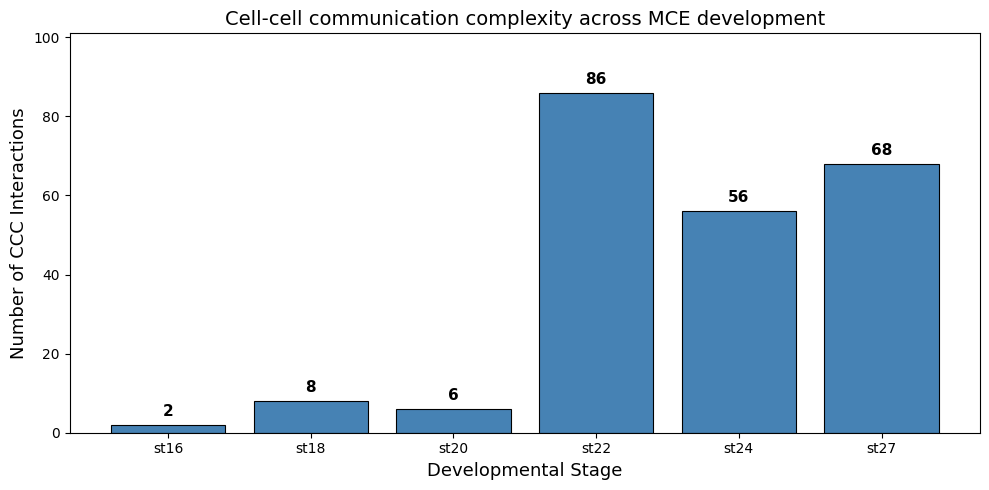

Saved: stagewise_interaction_counts.png


In [18]:
# ── PLOT 1: Interaction count trajectory across stages ────────────────────────

stage_counts = all_results.groupby('stage', observed=True).size().reset_index(name='n_interactions')

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    stage_counts['stage'].astype(str),
    stage_counts['n_interactions'],
    color='steelblue',
    edgecolor='black',
    linewidth=0.8
)

# Annotate bars with counts
for i, row in stage_counts.iterrows():
    ax.text(
        i, row['n_interactions'] + 1.5,
        str(row['n_interactions']),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Developmental Stage', fontsize=13)
ax.set_ylabel('Number of CCC Interactions', fontsize=13)
ax.set_title('Cell-cell communication complexity across MCE development', fontsize=14)
ax.set_ylim(0, stage_counts['n_interactions'].max() + 15)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'stagewise_interaction_counts.png'), dpi=150)
plt.show()
print("Saved: stagewise_interaction_counts.png")

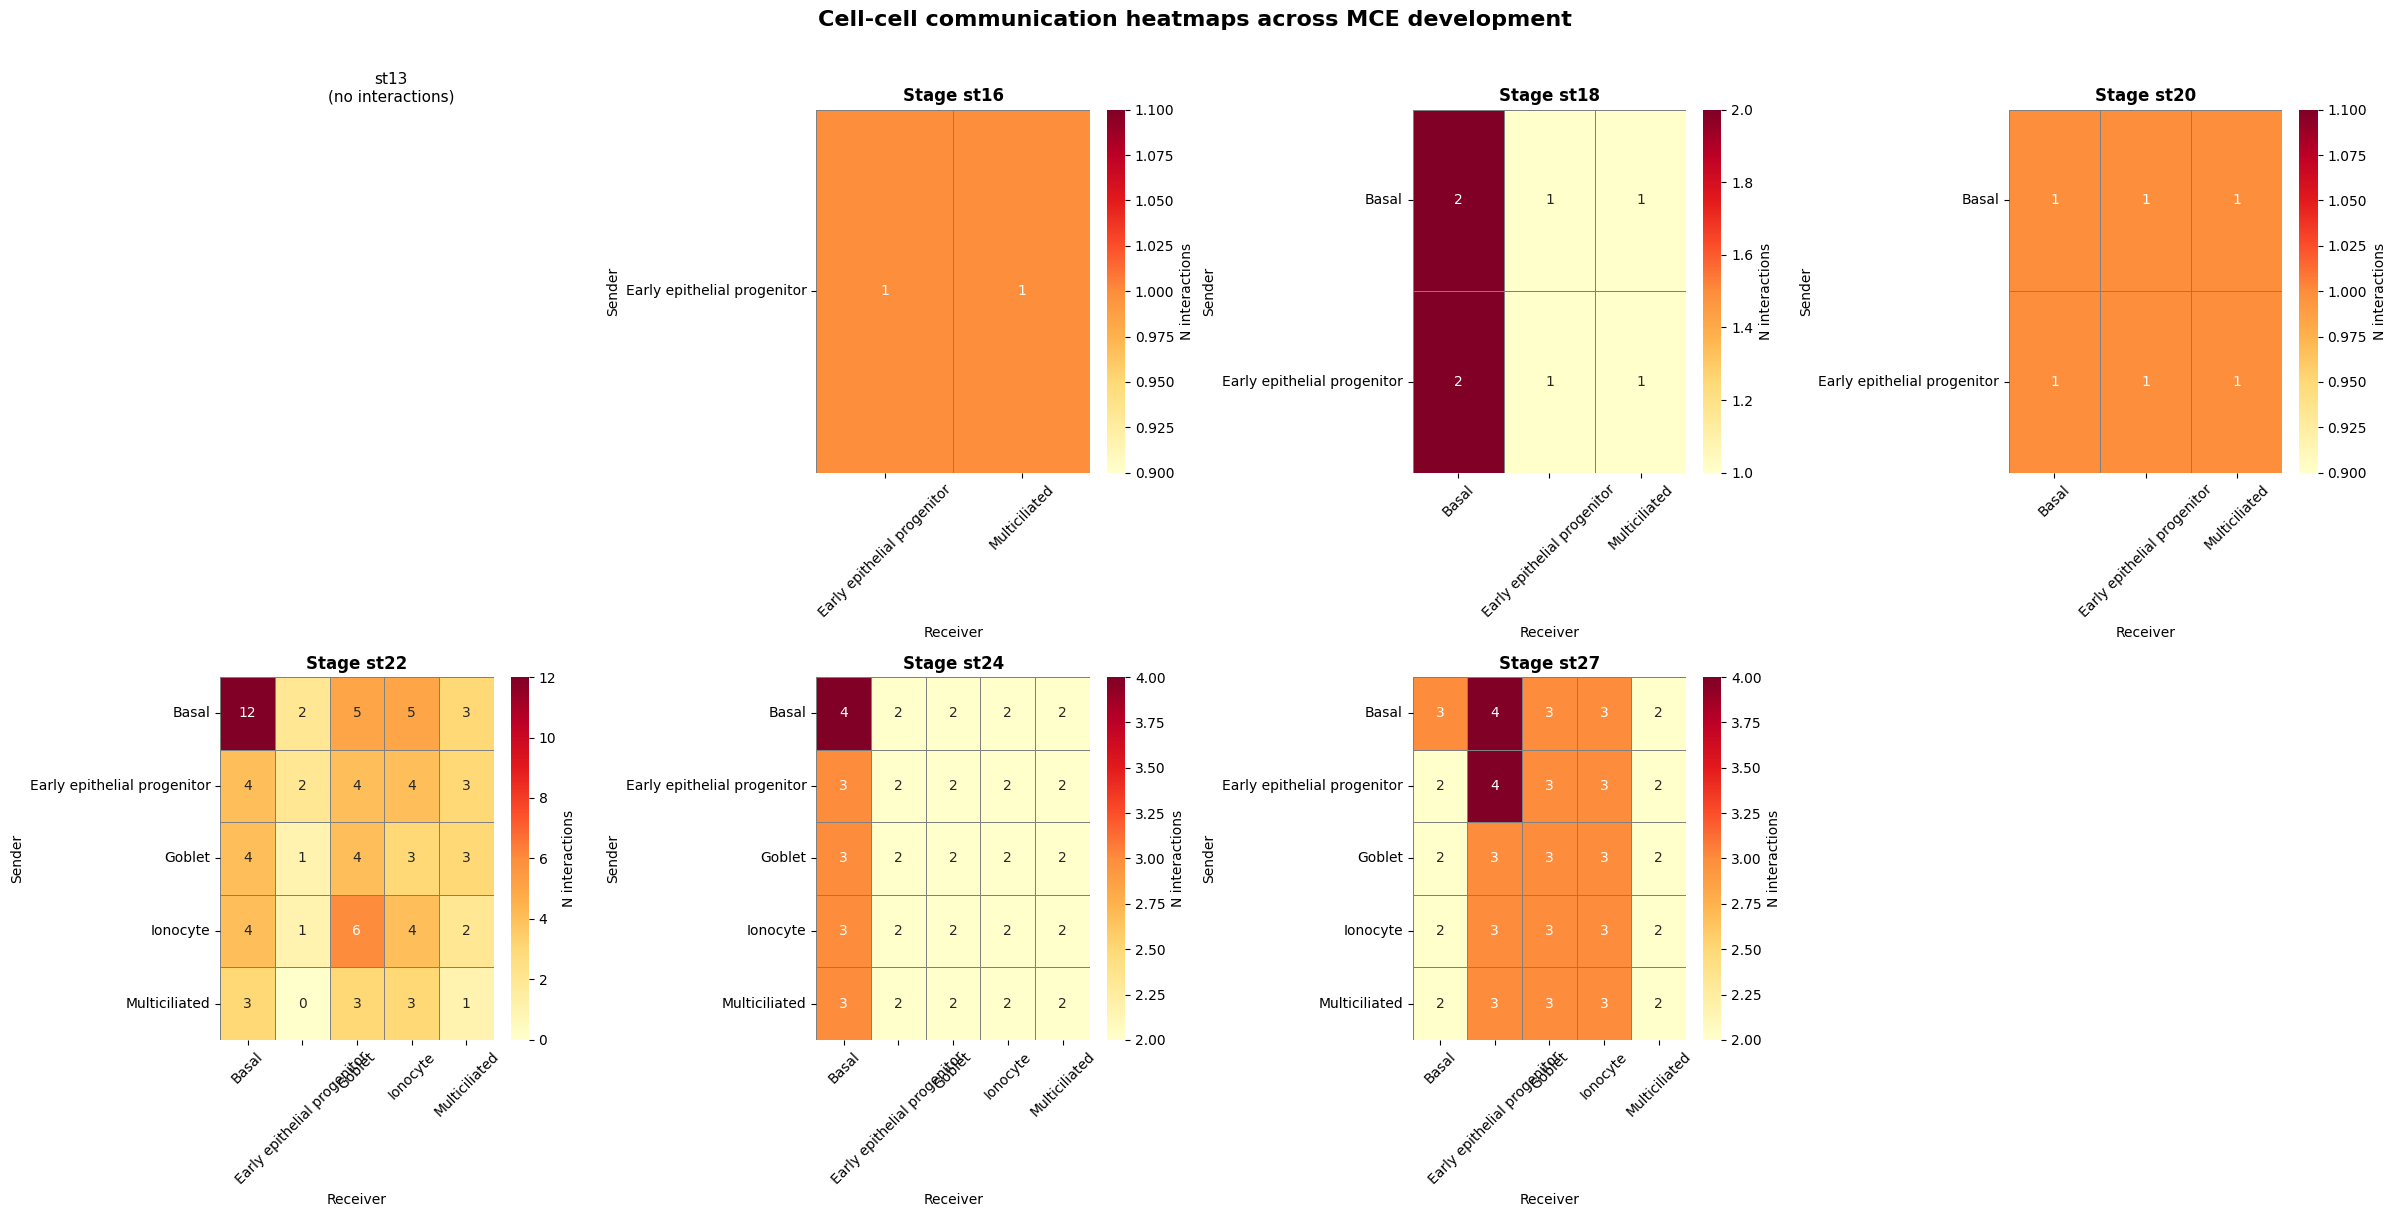

Saved: stagewise_ccc_heatmaps.png


In [19]:
# ── PLOT 2: Per-stage CCC heatmaps (sender x receiver) ───────────────────────

# Fix: just use STAGE_ORDER directly, handle empty stages inside the loop
fig, axes = plt.subplots(
    2, 4,
    figsize=(24, 12)
)
axes = axes.flatten()

for idx, stage in enumerate(STAGE_ORDER):
    ax = axes[idx]
    stage_df = all_results[all_results['stage'] == stage]

    if len(stage_df) == 0:
        ax.set_title(f'{stage}\n(no interactions)', fontsize=11)
        ax.axis('off')
        continue

    # Build pivot table
    pivot = pd.crosstab(
        stage_df['source'],
        stage_df['target']
    )

    sns.heatmap(
        pivot,
        ax=ax,
        cmap='YlOrRd',
        linewidths=0.5,
        linecolor='grey',
        annot=True,
        fmt='d',
        cbar_kws={'label': 'N interactions'}
    )

    ax.set_title(f'Stage {stage}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Receiver', fontsize=10)
    ax.set_ylabel('Sender', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

# Hide unused subplot panels
for idx in range(len(STAGE_ORDER), len(axes)):
    axes[idx].axis('off')

plt.suptitle(
    'Cell-cell communication heatmaps across MCE development',
    fontsize=16, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, 'stagewise_ccc_heatmaps.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: stagewise_ccc_heatmaps.png")

Stages included in plots: ['st16', 'st18', 'st20', 'st22', 'st24', 'st27']


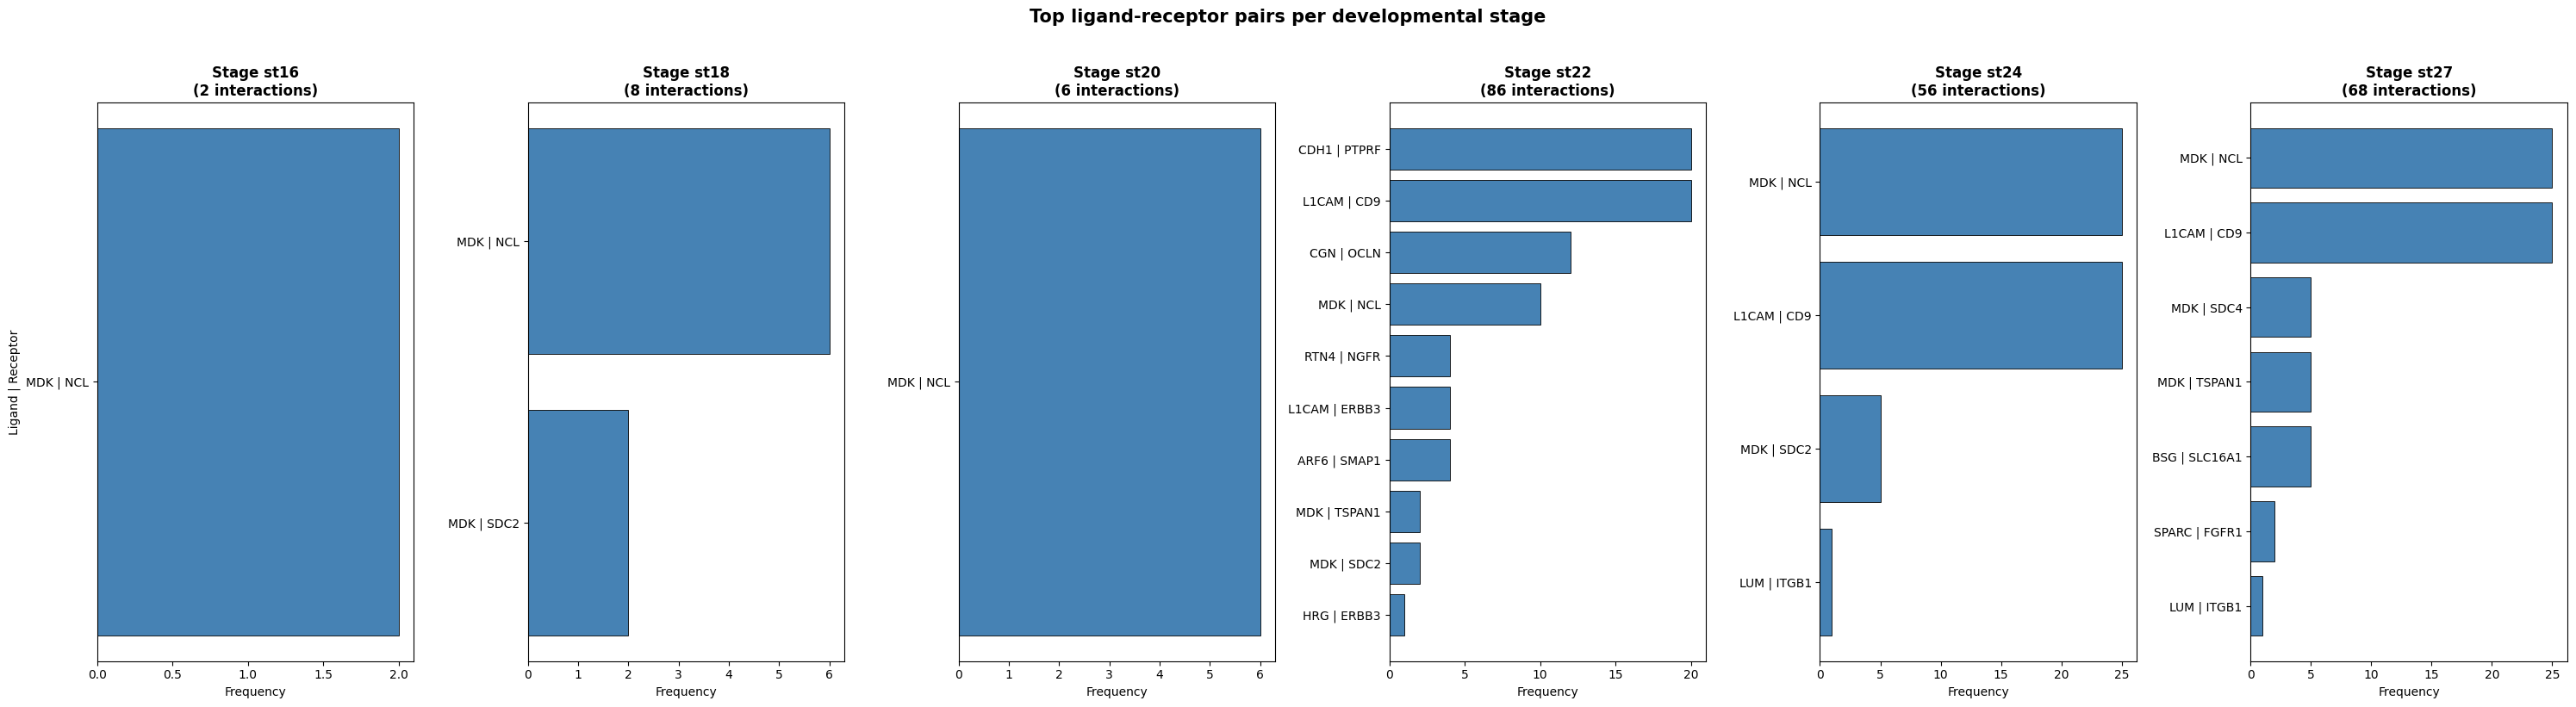

Saved: stagewise_top_lr_pairs.png


In [20]:
# ── PLOT 3: Top LR pairs per stage (ALL stages with interactions) ─────────────

meaningful_stages = [
    stage for stage in STAGE_ORDER
    if len(all_results[all_results['stage'] == stage]) > 0
]
print("Stages included in plots:", meaningful_stages)

n_stages = len(meaningful_stages)
fig, axes = plt.subplots(
    1, n_stages,
    figsize=(5 * n_stages, 8)
)

# Handle case where only 1 stage (makes axes not a list)
if n_stages == 1:
    axes = [axes]

for idx, stage in enumerate(meaningful_stages):
    ax = axes[idx]
    stage_df = all_results[all_results['stage'] == stage].copy()

    if len(stage_df) == 0:
        ax.axis('off')
        continue

    # Create LR pair label
    stage_df['lr_pair'] = (
        stage_df['ligand_complex'] + ' | ' + stage_df['receptor_complex']
    )

    # Count frequency of each LR pair
    lr_counts = (
        stage_df['lr_pair']
        .value_counts()
        .head(10)
        .reset_index()
    )
    lr_counts.columns = ['lr_pair', 'count']

    ax.barh(
        lr_counts['lr_pair'],
        lr_counts['count'],
        color='steelblue',
        edgecolor='black',
        linewidth=0.6
    )
    ax.invert_yaxis()
    ax.set_title(f'Stage {stage}\n({len(stage_df)} interactions)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency', fontsize=10)
    if idx == 0:
        ax.set_ylabel('Ligand | Receptor', fontsize=10)

plt.suptitle(
    'Top ligand-receptor pairs per developmental stage',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, 'stagewise_top_lr_pairs.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: stagewise_top_lr_pairs.png")

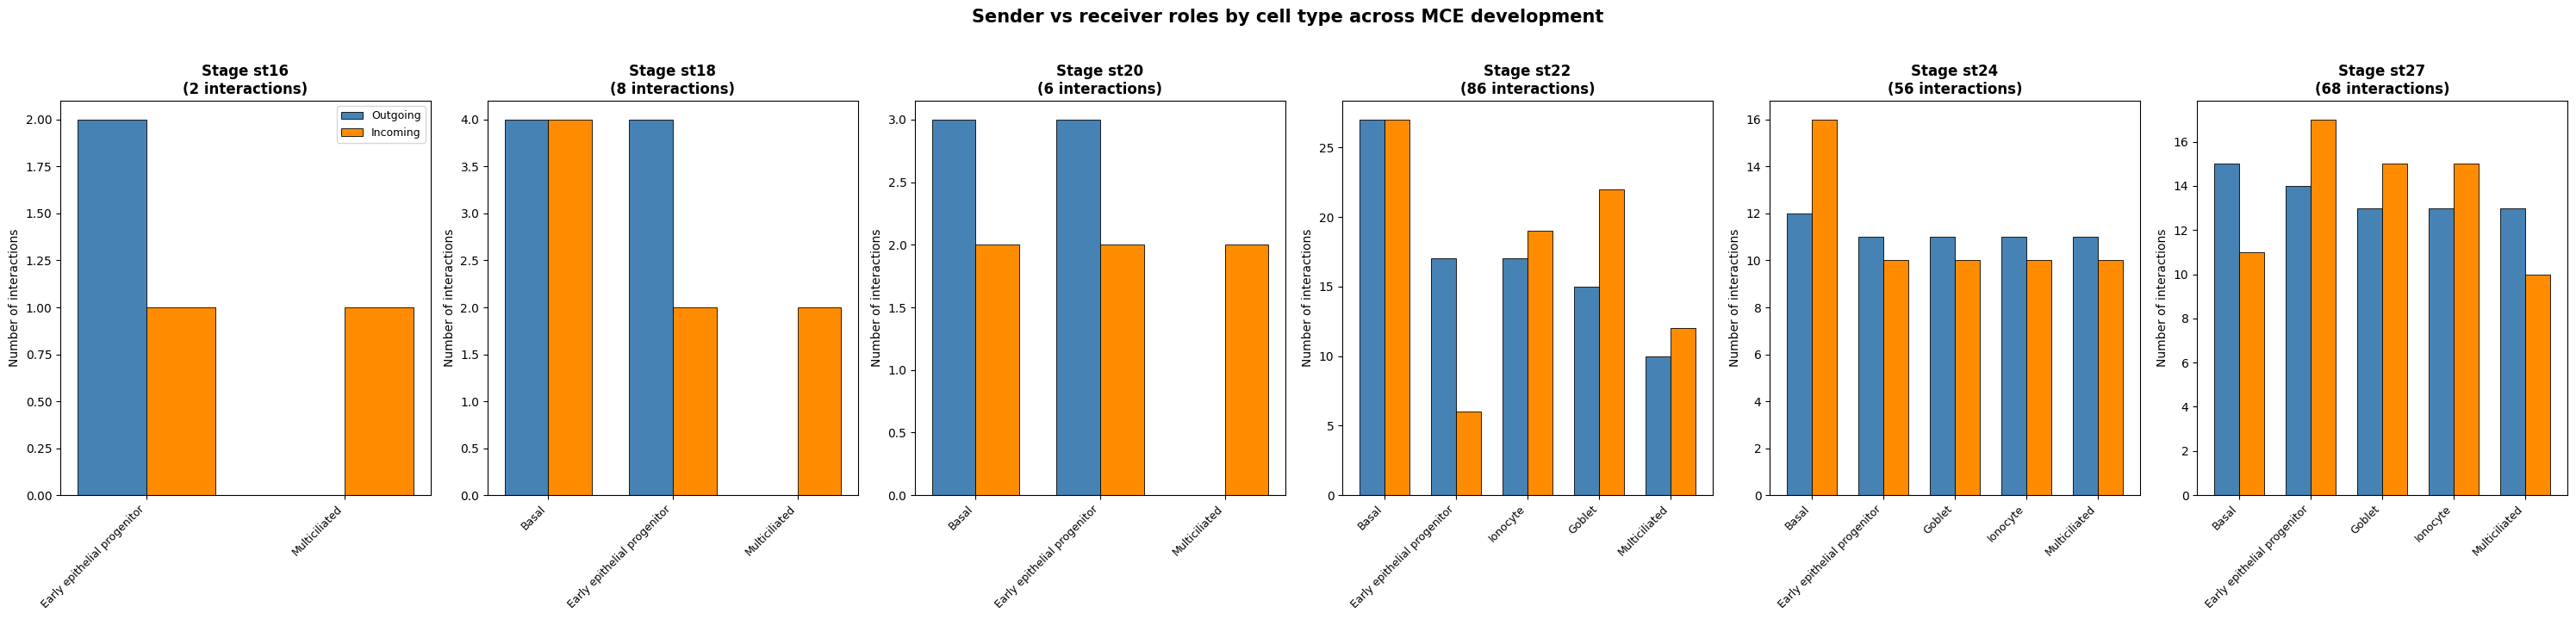

Saved: stagewise_sender_receiver_roles.png


In [21]:
# ── PLOT 4: Sender/receiver role evolution (ALL stages with interactions) ──────

fig, axes = plt.subplots(
    1, n_stages,
    figsize=(5 * n_stages, 7)
)

# Handle case where only 1 stage
if n_stages == 1:
    axes = [axes]

for idx, stage in enumerate(meaningful_stages):
    ax = axes[idx]
    stage_df = all_results[all_results['stage'] == stage]

    if len(stage_df) == 0:
        ax.axis('off')
        continue

    outgoing = stage_df.groupby('source').size().rename('Outgoing')
    incoming = stage_df.groupby('target').size().rename('Incoming')

    role_df = pd.DataFrame({
        'Outgoing': outgoing,
        'Incoming': incoming
    }).fillna(0).astype(int)
    role_df = role_df.sort_values('Outgoing', ascending=False)

    x = np.arange(len(role_df))
    width = 0.35

    ax.bar(
        x - width/2, role_df['Outgoing'], width,
        label='Outgoing', color='steelblue',
        edgecolor='black', linewidth=0.6
    )
    ax.bar(
        x + width/2, role_df['Incoming'], width,
        label='Incoming', color='darkorange',
        edgecolor='black', linewidth=0.6
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        role_df.index, rotation=45, ha='right', fontsize=9
    )
    ax.set_title(
        f'Stage {stage}\n({len(stage_df)} interactions)',
        fontsize=12, fontweight='bold'
    )
    ax.set_ylabel('Number of interactions', fontsize=10)

    # Only show legend on first panel
    if idx == 0:
        ax.legend(fontsize=9)

plt.suptitle(
    'Sender vs receiver roles by cell type across MCE development',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, 'stagewise_sender_receiver_roles.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: stagewise_sender_receiver_roles.png")

/var/folders/sz/r3cm0bns4rjbh99hyh5n2_c80000gn/T/ipykernel_58578/3629994758.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


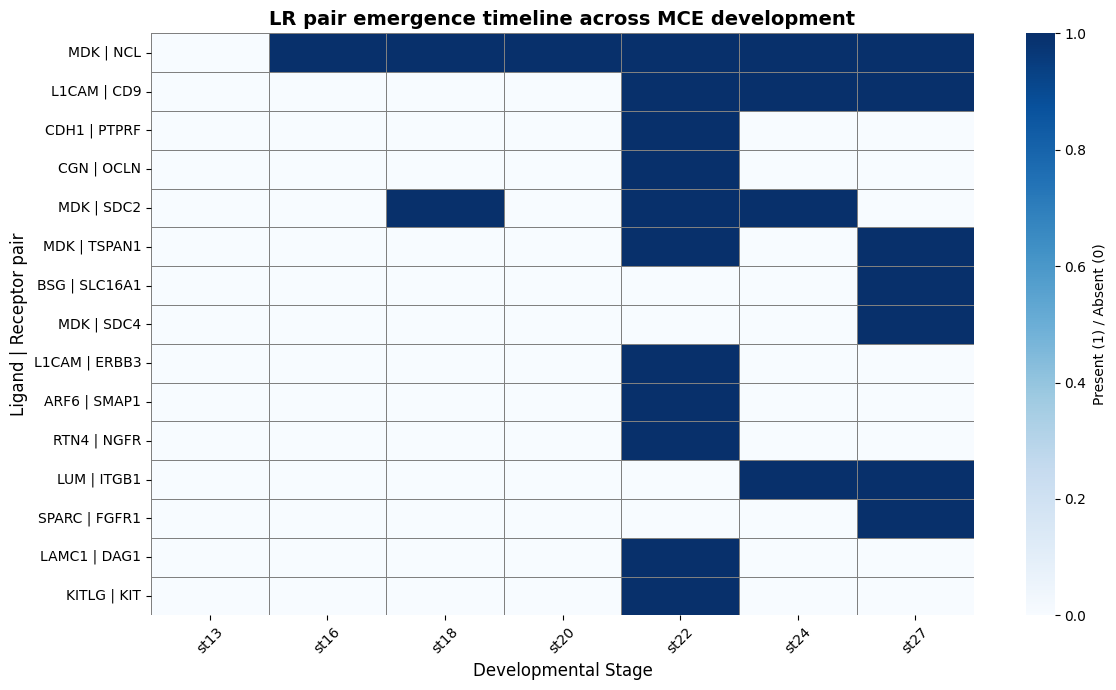

Saved: stagewise_lr_emergence_timeline.png


In [22]:
# ── PLOT 5: LR pair emergence timeline ───────────────────────────────────────
# Which LR pairs appear first and persist across stages?

all_results['lr_pair'] = (
    all_results['ligand_complex'] + ' | ' + all_results['receptor_complex']
)

# Get top 15 most frequent LR pairs overall
top_lr = all_results['lr_pair'].value_counts().head(15).index.tolist()

# Build presence matrix: LR pair × stage
presence = pd.DataFrame(index=top_lr, columns=STAGE_ORDER)

for stage in STAGE_ORDER:
    stage_df = all_results[all_results['stage'] == stage]
    for lr in top_lr:
        presence.loc[lr, stage] = int(lr in stage_df['lr_pair'].values)

presence = presence.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    presence,
    ax=ax,
    cmap='Blues',
    linewidths=0.5,
    linecolor='grey',
    cbar_kws={'label': 'Present (1) / Absent (0)'},
    vmin=0, vmax=1
)

ax.set_title('LR pair emergence timeline across MCE development', fontsize=14, fontweight='bold')
ax.set_xlabel('Developmental Stage', fontsize=12)
ax.set_ylabel('Ligand | Receptor pair', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(
    os.path.join(figures_dir, 'stagewise_lr_emergence_timeline.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Saved: stagewise_lr_emergence_timeline.png")

In [23]:
# ── Summary print ─────────────────────────────────────────────────────────────

print("\n=== All figures saved to:", figures_dir, "===")
print("1. stagewise_interaction_counts.png")
print("2. stagewise_ccc_heatmaps.png")
print("3. stagewise_top_lr_pairs.png")
print("4. stagewise_sender_receiver_roles.png")
print("5. stagewise_lr_emergence_timeline.png")


=== All figures saved to: ../figures/stagewise_figures ===
1. stagewise_interaction_counts.png
2. stagewise_ccc_heatmaps.png
3. stagewise_top_lr_pairs.png
4. stagewise_sender_receiver_roles.png
5. stagewise_lr_emergence_timeline.png
